### pip install torchvision nltk


## **1. Data Loading Process**

For this assignment you will be using the [MS COCO Captions 2017](https://cocodataset.org/#captions-2017) dataset, which contains **captions/descriptions** of diverse images.

<img src="https://cocodataset.org/images/coco-examples.jpg" alt="COCO Examples" border="0" width="600">

**Download Commands:**

```bash
# Download images
wget http://images.cocodataset.org/zips/train2017.zip        # ~18GB, 118K images
wget http://images.cocodataset.org/zips/val2017.zip          # ~1GB, 5K images

# Download annotations (includes captions)
wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip  # ~241MB
```

After downloading, extract and organize the data:

```
coco/
├── images/
│   ├── train2017/
│   └── val2017/
└── annotations/
    ├── captions_train2017.json
    └── captions_val2017.json
```

You can use the official `pycocotools` library to load and parse the annotations:

```python
!pip install pycocotools
from pycocotools.coco import COCO

coco = COCO('annotations/captions_train2017.json')
```

In [14]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import nltk
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import random
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
from collections import Counter

from pycocotools.coco import COCO
from torch.nn.utils.rnn import pad_sequence
import textwrap
import torchvision.models as models
import math

nltk.download('punkt')
nltk.download('punkt_tab') 
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}")
# print(torch.version.cuda)
coco = COCO('coco/annotations/captions_train2017.json')
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on: {device}")

[nltk_data] Downloading package punkt to /Users/kendij/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kendij/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


loading annotations into memory...
Done (t=0.53s)
creating index...
index created!
Working on: mps


## **2. Defining Augmentations**

When applying **augmentations** to the `COCO Captions` dataset, it is important to note that these transformations should be applied **only to the images** and not to the captions.

Ensure that your **data augmentation pipeline** includes:
- A **normalization step** to scale pixel values appropriately.
- A **tensor conversion step** to transform images into tensors for model compatibility.
- Additional **augmentations of your choice**, such as random cropping, flipping, or color jittering, to enhance model generalization.


In [15]:
IMAGE_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

 ### Vocabulary class
 

In [16]:
class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold

        self.itos = {0 : "<pad>", 1 : "<sos>", 2 : "<eos>", 3 : "<unk>"}
        self.stoi = {"<pad>" : 0, "<sos>" : 1, "<eos>" : 2, "<unk>" : 3}

    def __len__(self):
        return len(self.itos)
    
  
    # def tokenize_eng(text):
        # return nltk.tokenize.word_tokenize(text.lower())
    
    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4

        for sentence in sentence_list:
            for word in nltk.tokenize.word_tokenize(sentence.lower()):
                frequencies[word] += 1

                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
    
    def numericalize(self, text):
        tokenized_text = nltk.tokenize.word_tokenize(text.lower())

        return [self.stoi["<sos>"]] + \
               [self.stoi.get(token, self.stoi["<unk>"]) for token in tokenized_text] + \
               [self.stoi["<eos>"]]


    
    

### COCO Dataset class
- connecting images and captions into one pipeling

In [17]:
class COCOCaptionsDataset(Dataset):
    def __init__(self, root, annFile, vocab, transform=None):
        self.root = root
        self.coco = COCO(annFile)

        self.ids = list(self.coco.anns.keys())

        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.ids)
    
    def __getitem__(self, idx):
        ann_id = self.ids[idx]
        caption = self.coco.anns[ann_id]['caption']

        image_id = self.coco.anns[ann_id]['image_id']
        image_info = self.coco.loadImgs(image_id)[0]

        img_path = os.path.join(self.root, image_info['file_name'])

        image = Image.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        numericalized_caption = self.vocab.numericalize(caption)

        # numericalized_caption.append(self.vocab.stoi["<sos>"])
        # numericalized_caption += self.vocab.numericalize(caption)

        # numericalized_caption.append(self.vocab.stoi["<eos>"])

        caption_tensor = torch.tensor(numericalized_caption)
        caption_length = len(caption_tensor)

        return image, caption_tensor, caption_length
    
    


In [18]:
def collate_fn(batch):
        images = torch.stack([item[0] for item in batch], dim=0)

        captions = [item[1] for item in batch]

        length = torch.tensor([item[2] for item in batch])

        padded_captions = pad_sequence(captions, batch_first=True, padding_value=0)

        attention_masks = (padded_captions == 0)

        return images, padded_captions, length, attention_masks

## 4. Visualizing Training Data
- extract a batch from the training `DataLoader` and plot the input-target pairs, at least 8 pairs for a clear rep
- visualize both the original and tokenized caption too

In [19]:
def visualize_batch(dataloader, vocab, num_samples=8):
    batch = next(iter(dataloader))
    images, padded_captions, length, attention_masks = batch

    num_samples = min(num_samples, images.size(0))

    sample_images = images[:num_samples].cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

    imgs_unnirmalized = sample_images * std + mean
    imgs_unnirmalized = torch.clamp(imgs_unnirmalized, 0, 1)

    imgs_np = imgs_unnirmalized.permute(0, 2, 3, 1).numpy()

    nrows = (num_samples + 1) // 2

    fig, axes = plt.subplots(nrows, 2, figsize=(15, 5 * nrows))
    axes = axes.flatten()

    # fig, axes = plt.subplots(num_samples // 2, 2, figsize=(15, 5 * (num_samples // 2)))
    # axes = axes.flatten()

    for i in range(num_samples):
        token_indices = padded_captions[i].cpu().numpy()
        tokens = [vocab.itos.get(idx, "<unk>") for idx in token_indices]
        clean_text = " ".join([t for t in tokens if t not in ["<pad>", "<sos>", "<eos>"]])

        axes[i].imshow(imgs_np[i])
        axes[i].axis("off")

        title = (f"Original/Cleaned: {clean_text}\n"f"Tokenized: {tokens}")
        wrapped_title = textwrap.fill(title, width=65)
        axes[i].set_title(wrapped_title, fontsize=10, loc='left')

    for j in range(num_samples, len(axes)):
        axes[j].axis("off")

    fig.tight_layout()
    plt.show()

# visualize_batch(dataloader_variable, vocab=Vocabulary, num_samples=4)

1. Extracting all captions to build the vocabulary...
2. Building Vocabulary...
Vocabulary built! Total words: 10322
3. Creating Dataset...
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
4. Creating DataLoader...
5. Visualizing a batch!


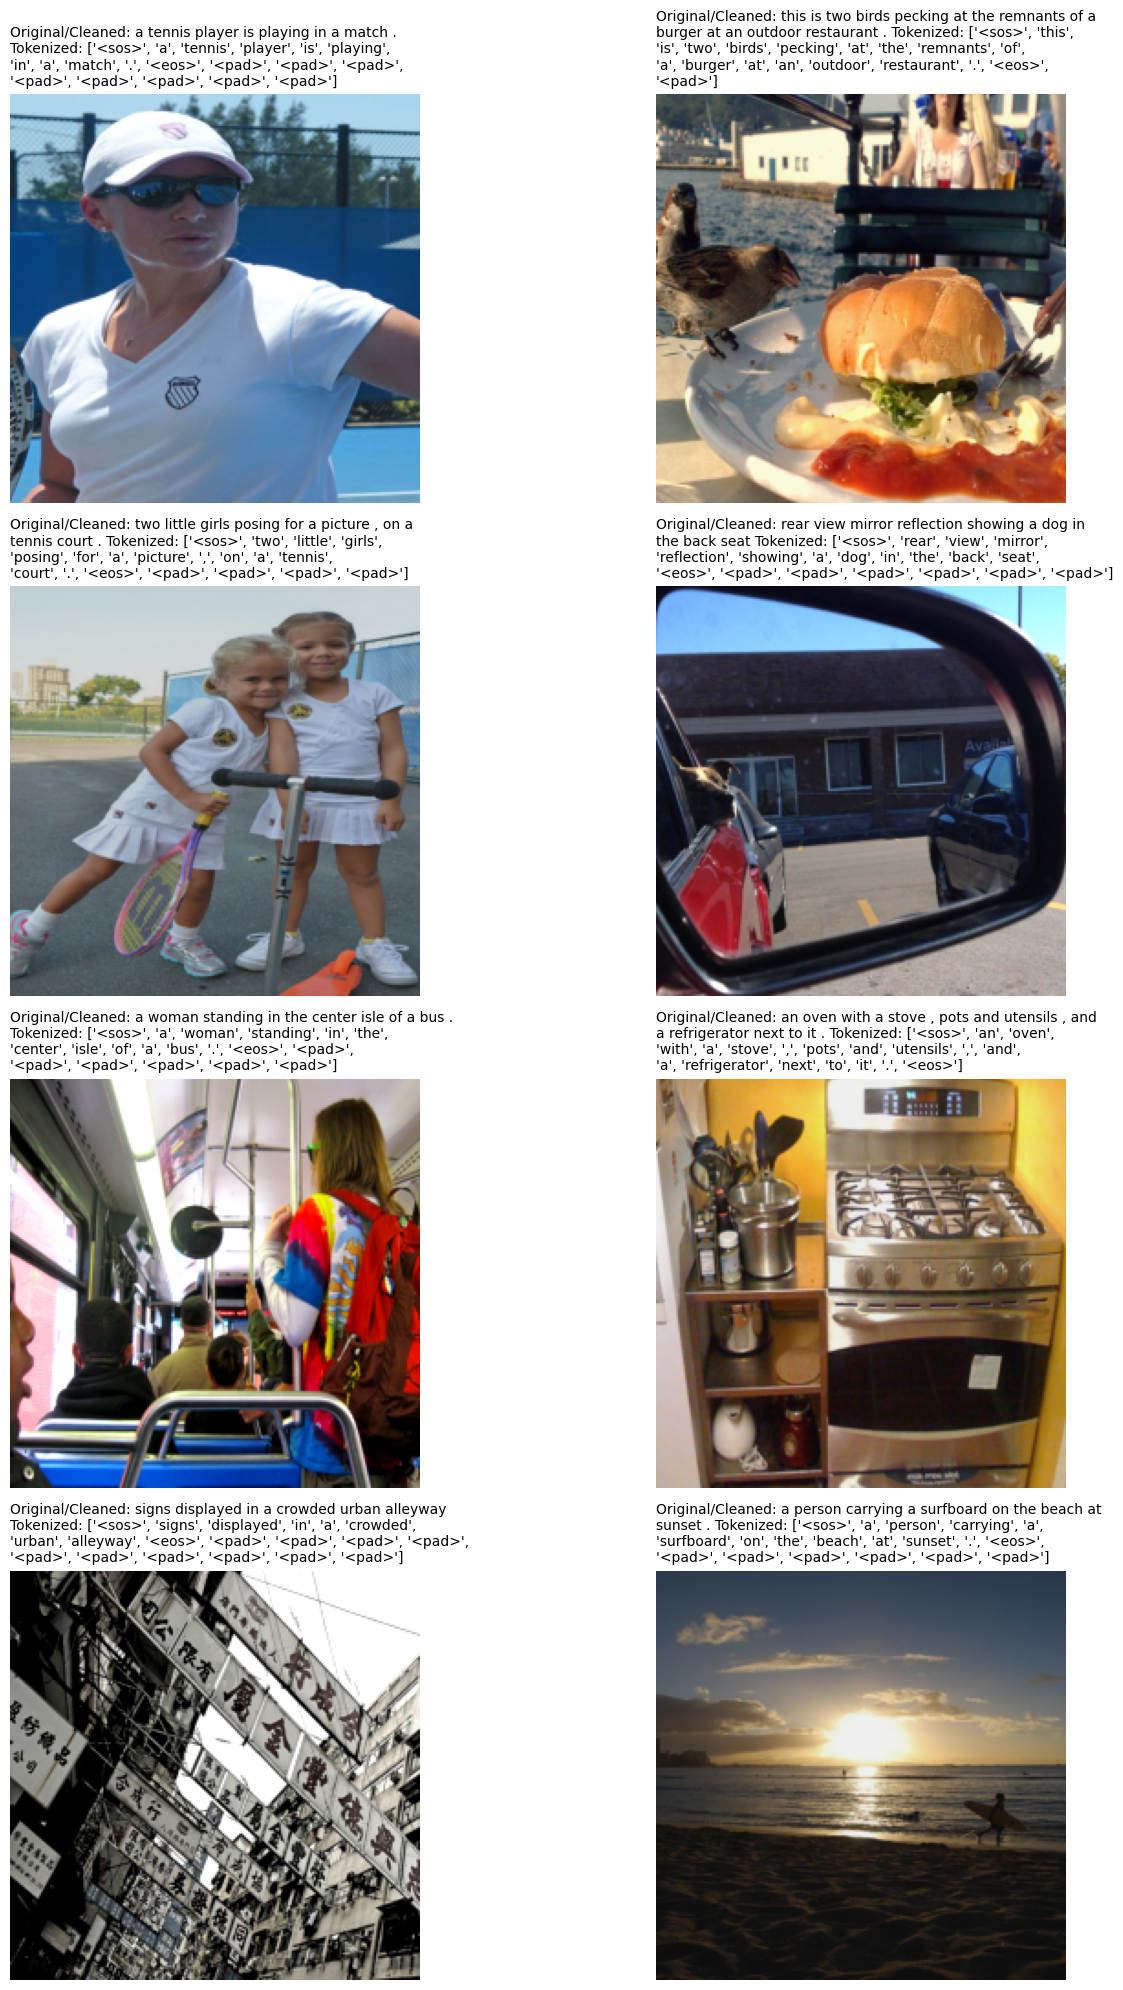

In [20]:


print("1. Extracting all captions to build the vocabulary...")
ann_ids = list(coco.anns.keys())
all_captions = [coco.anns[ann_id]['caption'] for ann_id in ann_ids]

print("2. Building Vocabulary...")
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(all_captions)
print(f"Vocabulary built! Total words: {len(vocab)}")

print("3. Creating Dataset...")
train_dataset = COCOCaptionsDataset(
    root='coco/images/val2017', 
    annFile='coco/annotations/captions_val2017.json', 
    vocab=vocab, 
    transform=train_transforms
)

print("4. Creating DataLoader...")
train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=8, 
    shuffle=True, 
    collate_fn=collate_fn 
)

print("5. Visualizing a batch!")
visualize_batch(train_loader, vocab, num_samples=8)

## Creating the Image Captioning Model
- Encoder-Attention-Transformer Decoder Architecture

In [21]:
class CNNEncoder(nn.Module):
    def __init__(self, encoder_dim=2048, fine_tune_from=6):
        super(CNNEncoder, self).__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        for idx, child in enumerate(self.resnet.children()):
            if idx < fine_tune_from:
                for param in child.parameters():
                    param.requires_grad = False
            else:
                for param in child.parameters():
                    param.requires_grad = True

    def forward(self, images):
        features = self.resnet(images)
        batch_size, channels, h, w = features.shape
        features = features.view(batch_size, channels, -1)
        features = features.permute(0, 2, 1)

        return features
    

    





In [22]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [23]:
class TransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, dim_feedforward, dropout=0.1):
        super(TransformerDecoderLayer, self).__init__()

        self.self_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        tgt2, _ = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask, key_padding_mask=tgt_key_padding_mask)
        tgt = tgt + self.dropout1(tgt2)
        tgt = self.norm1(tgt)

        tgt2, cross_attn_weights = self.cross_attn(tgt, memory, memory, need_weights=True)
        tgt = tgt + self.dropout2(tgt2)
        tgt = self.norm2(tgt)

        tgt2 = self.linear2(self.dropout(F.relu(self.linear1(tgt))))
        tgt = tgt + self.dropout3(tgt2)
        tgt = self.norm3(tgt)

        return tgt, cross_attn_weights
    

In [24]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, dim_feedforward, dropout=0.1):
        super(TransformerDecoder, self).__init__()
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        self.control_embedding = nn.Embedding(3, d_model)
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(d_model, num_heads, dim_feedforward, dropout) 
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, captions, encoder_features, tgt_mask=None, control_signal=None):
        x = self.word_embedding(captions)

        if control_signal is not None:
            ctrl_emb = self.control_embedding(control_signal).unsqueeze(1) 
            x = x + ctrl_emb
        
        x = self.pos_encoder(x)

        all_cross_attn_weights = []
        for layer in self.layers:
            x, cross_attn_weights = layer(x, encoder_features, tgt_mask=tgt_mask)
            all_cross_attn_weights.append(cross_attn_weights)

        logits = self.fc_out(x)
        return logits, all_cross_attn_weights
    
    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask
    

In [25]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, vocab_size, encoder_dim, d_model, num_heads, num_layers, dim_feedforward):
        super(ImageCaptioningModel, self).__init__()
        self.encoder = CNNEncoder(encoder_dim=encoder_dim)

        self.enc_proj = nn.Linear(encoder_dim, d_model) if encoder_dim != d_model else nn.Identity()
        
        self.decoder = TransformerDecoder(vocab_size, d_model, num_heads, num_layers, dim_feedforward)

    def forward(self, images, captions, control_signal=None):
        features = self.encoder(images)
        features = self.enc_proj(features)

        seq_len = captions.size(1)
        tgt_mask = self.decoder.generate_square_subsequent_mask(seq_len).to(images.device)

        logits, cross_attn_weights = self.decoder(captions, features, tgt_mask, control_signal)
        return logits, cross_attn_weights
    
    def generate(self, images, max_len=50, control_signal=None, start_token_idx=1, end_token_idx=2):
        self.eval()

        with torch.no_grad():
            batch_size = images.size(0)

            features = self.encoder(images)
            features = self.enc_proj(features)

            generated = torch.full((batch_size, 1), start_token_idx, dtype=torch.long, device=images.device)

            for _ in range(max_len):
                tgt_mask = self.decoder.generate_square_subsequent_mask(generated.size(1)).to(images.device)

                logits, attn_weights = self.decoder(generated, features, tgt_mask, control_signal)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                generated = torch.cat((generated, next_token), dim=1)

                if (generated == end_token_idx).any(dim=1).all():
                    break
            return generated, attn_weights[-1]